# Orientation optimization for a planar transient heat problem
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/meyer-nils/torch-fem/blob/main/examples/optimization/planar/orientation_thermal_transient.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/meyer-nils/torch-fem/main?labpath=examples/optimization/planar/orientation_thermal_transient.ipynb)

Achieve faster global conductivity by optimizing local material orientation.

In [1]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import torch
from matplotlib import animation, colormaps
from tqdm import tqdm

from torchfem.data import get_data
from torchfem.io import import_mesh
from torchfem.materials import OrthotropicConductivity2D
from torchfem.planar import PlanarHeat
from torchfem.plot_utils import embed_animation_gif
from torchfem.rotations import planar_rotation

# Set default data type to double precision
torch.set_default_dtype(torch.float64)

## Transient heat equation on planar domain

In [2]:
# Dimensions (thickness of plate t and edge length L)
t = 0.01
L = 0.2

# Material properties
kappa_l = 500.0
kappa_t = 50.0
rho = 7850.0
cp = 500.0

In [3]:
# Material model (thermal mass is rho*cp)
material = OrthotropicConductivity2D(kappa_1=kappa_l, kappa_2=kappa_t, rho=rho * cp)

# Import mesh with the origin in its center
mesh = import_mesh(get_data("plate_hole.vtk"), material)
mesh.nodes[:, :2] -= 0.5 * L

plate = PlanarHeat(mesh.nodes, mesh.elements, material)
plate.thickness[:] = t

# Fixed temperature at right end
left = plate.nodes[:, 0] < -0.5 * L + 1e-6
right = plate.nodes[:, 0] > 0.5 * L - 1e-6
plate.constraints[right] = True
plate.temperatures[right, 0] = 20.0

# Solver settings
end_time = 120.0
delta_t = 1.0

# Results are returned at exactly these times. They are equidistant, as the
# objective below integrates over them.
times = torch.arange(0.0, end_time + delta_t, delta_t)

# Solve
temp_init, *_ = plate.time_integration(times, delta_t, verbose=False)

### Solve initial configuraton

the main material axis is the global x-axis. 

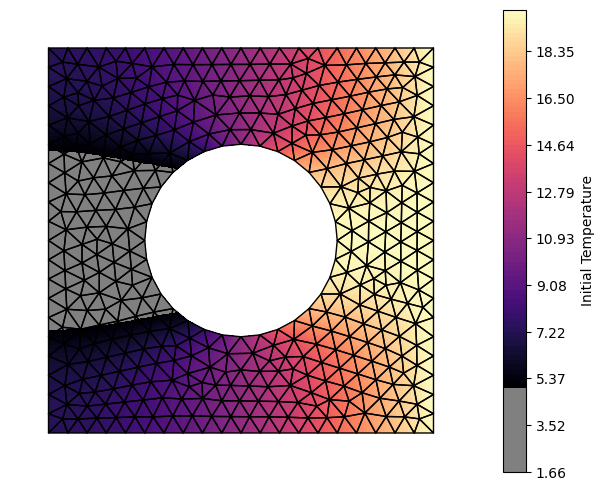

In [4]:
vmin, vmax = 5.0, 20.0
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# Values below vmin are drawn in gray
cmap = colormaps["magma"].copy()
cmap.set_under("gray")

plate.plot(
    node_property={"Initial Temperature": temp_init[90, :, 0]},
    vmin=vmin,
    vmax=vmax,
    cmap=cmap,
    norm=norm,
    colorbar=True,
    bcs=False,
)

The heat flux might not be optimal. Due to smaller transverse conducitiy, heat transfer in $y$-direction is smaller. Hence, this region is not fully heated up to 5° after 100 seconds.  

\
Temperatures below $T_\text{min}$ at the left edge are penalized and summed up for each timestep.

$f = \int_{0}^{t_{\text{end}}} \int_{-H/2}^{H/2} \left(\mathrm{clamp}\left( \left. T \right|_{x=-L/2}, -\infty, T_\text{min}  \right) - T_\text{min} \right)^2 \, \mathrm{d}y \mathrm{d}t$

We implement the discretized version below, exploiting equdistant temporal and spatial increments.

In [5]:
target_temp = 5.0


def delta_temp_left(phi):
    rotation = planar_rotation(phi)

    plate.material = material.vectorize(plate.n_elem).rotate(rotation)
    temp, *_ = plate.time_integration(times, delta_t, differentiable_parameters=phi)

    loss = (torch.clamp(temp[:, left, :], -1e64, target_temp) - target_temp) ** 2.0

    return loss.sum()

### Unconstrained Optimization

Orientations in each element are initialized with $0°$.


> Actually, $\mathfrak{so}(1)$ is not the perfect metric space for our design variable, since $\boldsymbol{R} \star \boldsymbol{\kappa} = \left(-\boldsymbol{R}\right) \star \boldsymbol{\kappa}$. 

In [6]:
phi = torch.zeros(len(plate.elements), requires_grad=True)

optimizer = torch.optim.Adam([phi], lr=0.1)

loss_it = []
for _ in tqdm(range(50)):
    optimizer.zero_grad()
    objective = delta_temp_left(phi)
    loss_it.append(objective.detach().item())

    objective.backward()
    optimizer.step()

100%|██████████| 50/50 [00:38<00:00,  1.31it/s]


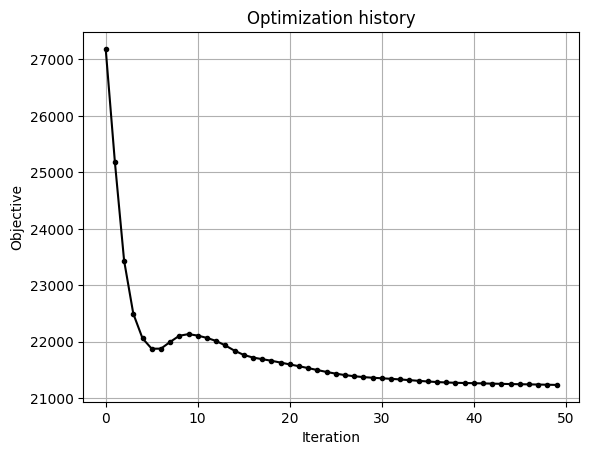

In [7]:
plt.plot(loss_it, ".-k")
plt.title("Optimization history")
plt.xlabel("Iteration")
plt.ylabel("Objective")
plt.grid()
plt.show()

### Compute the solution with optimized orientations.

In [8]:
temp_opti, *_ = plate.time_integration(times, delta_t)

plate.material = material.vectorize(len(plate.elements)).rotate(
    planar_rotation(0.5 * torch.pi)
)
temp_90, *_ = plate.time_integration(times, delta_t)

### Animate the temperature evolution for the naive guess (globally 0°), the naive worst case (globally 90°) and for the optimized design. 


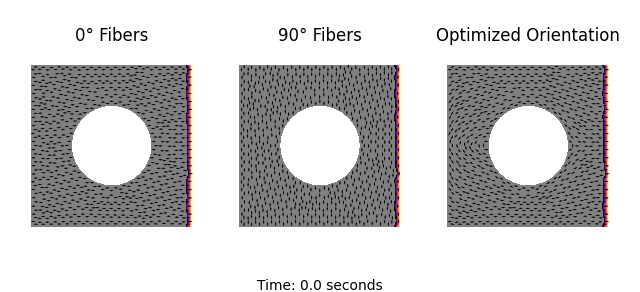

In [9]:
fig, axes = plt.subplots(1, 3)
time_text = fig.text(0.5, 0.0, "Time: 0.0 seconds", ha="center", va="bottom")
fig.set_figheight(fig.get_figheight() * 0.61)
fig.set_layout_engine("tight")

# Each state is a temperature history and the orientation field that produced it
centers = plate.nodes[plate.elements].mean(dim=-2)
states = [
    (temp_init, "0° Fibers", torch.zeros_like(phi)),
    (temp_90, "90° Fibers", torch.full_like(phi, 0.5 * torch.pi)),
    (temp_opti, "Optimized Orientation", phi.detach()),
]


def animate(i):
    # Matplotlib cannot update tricontour data in place, so redraw each frame
    for ax, (temp, title, angle) in zip(axes, states):
        ax.clear()
        plate.plot(
            node_property=temp[i].ravel(),
            cmap=cmap,
            norm=norm,
            title=title,
            ax=ax,
            vmin=vmin,
            vmax=vmax,
            linewidth=0.0,
            bcs=False,
        )
        # Orientations are axes, not directions, so draw them both ways
        for sign in (1.0, -1.0):
            ax.quiver(
                centers[:, 0],
                centers[:, 1],
                sign * torch.cos(angle),
                sign * torch.sin(angle),
                pivot="middle",
            )
    time_text.set_text(f"Time: {i * delta_t:.1f} seconds")
    return (time_text,)


anim = animation.FuncAnimation(
    fig, animate, frames=range(0, len(temp_opti), 2), interval=20, repeat=False
)

plt.close(fig)  # prevent static plot
embed_animation_gif(anim, fps=10)